In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def deriv_sim(f,x):
    df = np.zeros_like(f)
    for i in range(1,len(x)-1):
        df[i] = (f[i+1]-f[i-1])/(x[i+1]-x[i-1])
    df[0] = 0.5*(-3*f[0] + 4*f[1] - f[2])/(x[1]-x[0])
    df[-1] = 0.5*(3*f[-1] - 4*f[-2] + f[-3])/(x[-1]-x[-2])
    return df

Consideremos un potencial
$$
V=\frac{1}{r^4} - \frac{2}{r^2}
$$

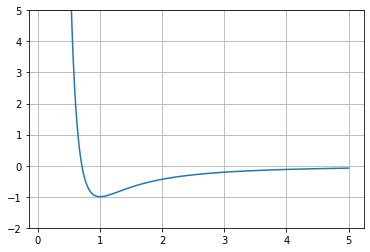

In [3]:
h = 1e-4
x = np.arange(0.1,5+h,h)
y = 1/x**4 - 2/x**2
plt.plot(x,y)
plt.ylim([-2,5])
plt.grid()
plt.show()

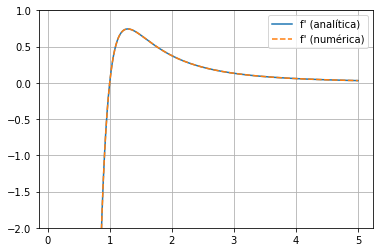

In [4]:
dy = -4/x**5 + 4/x**3
dy_num = deriv_sim(y,x)
plt.plot(x,dy,label=r"f' (analítica)")
plt.plot(x,dy_num,'--',label=r"f' (numérica)")
plt.ylim([-2,1])
plt.grid()
plt.legend()
plt.show()

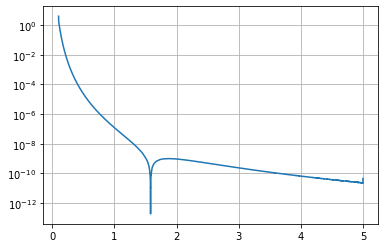

In [5]:
error = abs(dy - dy_num)
plt.semilogy(x,error)
#plt.ylim([0,1])
plt.grid()
plt.show()

Consideremos un potencial
$$
V=\xi^4 - 2\xi^2
$$

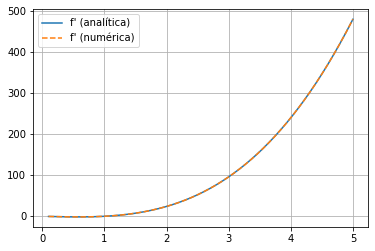

In [6]:
z = x**4 - 2*x**2
dz = 4*x**3 - 4*x
dz_num = deriv_sim(z,x)
plt.plot(x,dz,label=r"f' (analítica)")
plt.plot(x,dz_num,'--',label=r"f' (numérica)")
plt.grid(),plt.legend()
plt.show()

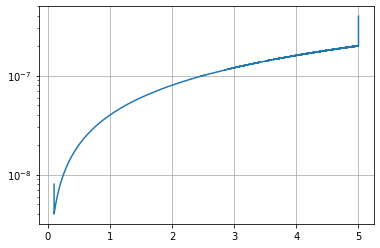

In [7]:
error_z = abs(dz-dz_num)
plt.semilogy(x,error_z)
plt.grid()
plt.show()

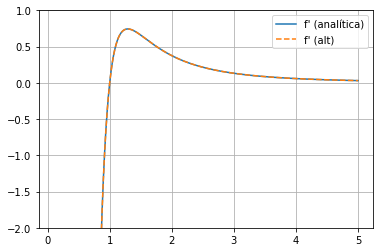

In [8]:
z1 = x**4
z2 = -2*x**2
dz1_num , dz2_num  = deriv_sim(z1,x) , deriv_sim(z2,x)
dy_alt = (16/dz1_num + 16/dz2_num)*(-1/x**2)
plt.plot(x,dy,label=r"f' (analítica)")
plt.plot(x,dy_alt,'--',label=r"f' (alt)")
plt.ylim([-2,1])
plt.grid(),plt.legend()
plt.show()

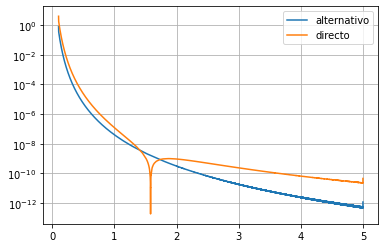

In [9]:
error_alt = abs(dy-dy_alt)
plt.semilogy(x,error_alt,label='alternativo')
plt.semilogy(x,error,label='directo')
plt.grid(),plt.legend()
plt.show()

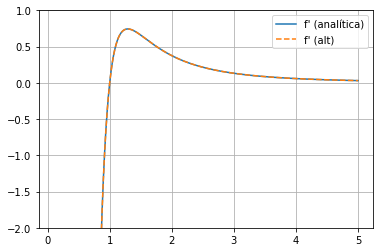

In [12]:
z1 = x**4
z2 = x**2
z_y = 1/x
dz1_num , dz2_num  = deriv_sim(z1,x) , deriv_sim(z2,x)
dzdx = deriv_sim(z_y,x)
dy_alt = (16/dz1_num - 8/dz2_num)*dzdx
plt.plot(x,dy,label=r"f' (analítica)")
plt.plot(x,dy_alt,'--',label=r"f' (alt)")
plt.ylim([-2,1])
plt.grid(),plt.legend()
plt.show()

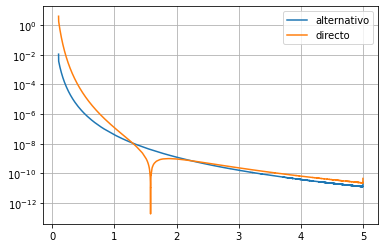

In [13]:
error_alt = abs(dy-dy_alt)
plt.semilogy(x,error_alt,label='alternativo')
plt.semilogy(x,error,label='directo')
plt.grid(),plt.legend()
plt.show()

______________

# Resolviendo el problema por partes

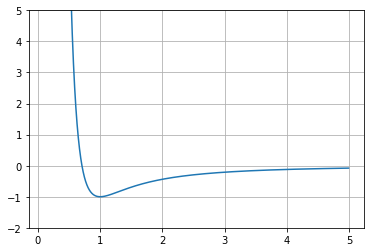

In [37]:
h1,h2,h3 = 1e-4 , 1e-3 , 1e-2
pt_empalme = 1
pt_empalme_2 = 2
x1 = np.arange(0.1,pt_empalme,h1)
x2 = np.arange(pt_empalme,pt_empalme_2,h2)
x3 = np.arange(pt_empalme_2,5,h3)
x = np.concatenate((x1,x2,x3))
y = 1/x**4 - 2/x**2
plt.plot(x,y)
plt.ylim([-2,5])
plt.grid()
plt.show()

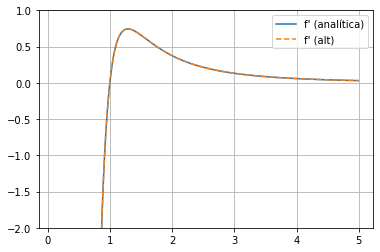

In [38]:
z1 = x**4
z2 = x**2
z_y = 1/x
dy = -4/x**5 + 4/x**3
dz1_num , dz2_num  = deriv_sim(z1,x) , deriv_sim(z2,x)
dzdx = deriv_sim(z_y,x)
dy_alt = (16/dz1_num - 8/dz2_num)*dzdx
plt.plot(x,dy,label=r"f' (analítica)")
plt.plot(x,dy_alt,'--',label=r"f' (alt)")
plt.ylim([-2,1])
plt.grid(),plt.legend()
plt.show()

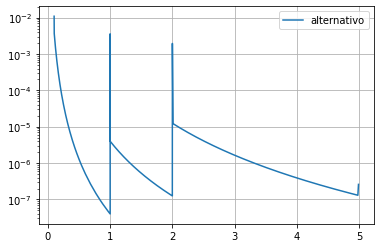

In [39]:
error_alt = abs(dy-dy_alt)
plt.semilogy(x,error_alt,label='alternativo')
plt.grid(),plt.legend()
plt.show()